## Notebook grammar

Open in Colab: https://colab.research.google.com/github/HNXJ/jaxfne/blob/main/tutorials/jaxfne-v035-coop-paradigm-stability.ipynb

setup -> config -> simulation/probe -> objective cells -> export

This notebook uses package APIs through `import jaxfne as jtfne`; editable inputs are centralized in config cells; readouts are proxy-scoped where named as proxies; exports use JSON/PNG receipts when artifacts are produced.


# v0.3.35 COOP / Paradigm Gate — Stability & Adaptation Tutorial


```python
import jaxfne as jtfne
```
This tutorial demonstrates the Continuous Omission Oddball Paradigm (COOP) implemented as a package-native API (`jtfne.coop_omission_oddball_paradigm`).
We show the generalizability of the COOP paradigm by running it on two separate models:
1. A 10-neuron dummy E-I model.
2. A duplicated/connected two-column model.

We also demonstrate how a PID-style control system adapts network parameters to stabilize spiking rate dynamics under the omission task.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jaxfne as jtfne

# Ensure x64 mode is initialized if desired
jtfne.enable_x64()

{'x64_enabled': True, 'status': 'enabled'}

## 1. Defining the Continuous Omission Oddball Paradigm (COOP)

We construct a standard COOP paradigm object with explicit target indices for stimulated neurons, standard triangular pulse amplitudes, and a continuous omission sequence.

In [2]:
duration_ms = 2000.0
dt_ms = 0.5
target_idx = [0, 1, 2, 3] # Explicit target indices for stimulation

coop_paradigm = jtfne.coop_omission_oddball_paradigm(
    duration_ms=duration_ms,
    dt_ms=dt_ms,
    freq_hz=6.0,
    omission_prob=0.2,
    standard_amplitude=8.0,
    pre_stimulus_buffer_ms=200.0,
    target_indices=target_idx,
    seed=42
)

print("Paradigm created successfully:", coop_paradigm.name)

Paradigm created successfully: coop_omission_oddball


## 2. Model 1: 10-Neuron Dummy E-I Model

We construct and simulate a basic 10-neuron model using package configuration and builders.

In [3]:
cfg_dummy = (
    jtfne.configuration()
    .network(name="dummy_10", kind="cortical_column", n=10, cell_types={"E": 0.8, "PV": 0.2})
    .emitter(family="izhikevich", preset="cortical_eig")
    .field(domain="laminar_column", conductivity="proxy", boundary="mean_zero_neumann", gauge="mean_zero")
    .probe(name="laminar_probe", modes=["spikes", "V_m", "CSD", "LFP"])
)
model_dummy = jtfne.construct(cfg_dummy)

sim = jtfne.simulation(duration_ms=duration_ms, dt_ms=dt_ms, seed=42)
signals_dummy = model_dummy.simulate(sim, paradigm=coop_paradigm)
readout_dummy = model_dummy.probe(signals_dummy, modes=["spikes", "V_m"])

print("Dummy model simulated successfully. Output shapes:", readout_dummy["spikes"].shape)

Dummy model simulated successfully. Output shapes: (4000, 10)


## 3. Model 2: Duplicated/Connected Two-Column Model

We use `jtfne` multi-area column builders to create two columns (ColA and ColB) connected with a manifest, and run the exact same paradigm.

In [4]:
cfg_connected = jtfne.build_multi_area_columns(["ColA", "ColB"], n_per_area=10, connectivity_mode="all_to_all")
cfg_connected = cfg_connected.set_probes(["spikes", "V_m", "CSD", "LFP"])
model_connected = jtfne.construct(cfg_connected)

signals_conn = model_connected.simulate(sim, paradigm=coop_paradigm)
readout_conn = model_connected.probe(signals_conn, modes=["spikes", "V_m"])

print("Connected model simulated successfully. Output shapes:", readout_conn["spikes"].shape)

Connected model simulated successfully. Output shapes: (4000, 20)


## 4. Stability Optimization (PID-Style Control Loop)

We implement a PID control adaptation loop adjusting the `drive_scale` parameter of the dummy model to stabilize the E-population firing rate close to a target of 10 Hz.

In [5]:
def calculate_stability_score(spikes, target_rate=10.0, dt_ms=0.5):
    n_steps, n_neurons = spikes.shape
    total_time_sec = (n_steps * dt_ms) / 1000.0
    rates = np.sum(spikes, axis=0) / total_time_sec
    rmse = np.sqrt(np.mean((rates - target_rate)**2))
    score = max(0.0, 100.0 - 5.0 * rmse)
    return float(score), float(np.mean(rates))

# User-facing configuration variables for manual edits
starting_drive_scale = 0.5
target_firing_rate = 10.0
tuning_gain = 0.08

current_scale = starting_drive_scale
print(f"Starting PID adaptation loop. Target rate: {target_firing_rate} Hz")

for step in range(4):
    # Apply parameter edit via package API
    tuned_model = jtfne.with_emitter_parameters(model_dummy, drive_scale=float(current_scale))
    sigs = tuned_model.simulate(sim, paradigm=coop_paradigm)
    ro = tuned_model.probe(sigs, modes=["spikes"])
    spks = np.array(ro["spikes"])
    
    score, mean_rate = calculate_stability_score(spks, target_rate=target_firing_rate, dt_ms=dt_ms)
    print(f"Step {step}: scale={current_scale:.3f} -> Rate: {mean_rate:.2f} Hz, Stability Score: {score:.2f}")
    
    # Update parameter via simple proportional control
    error = target_firing_rate - mean_rate
    current_scale = max(0.1, current_scale + tuning_gain * error)

Starting PID adaptation loop. Target rate: 10.0 Hz
Step 0: scale=0.500 -> Rate: 0.00 Hz, Stability Score: 50.00
Step 1: scale=1.300 -> Rate: 15.60 Hz, Stability Score: 69.73


Step 2: scale=0.852 -> Rate: 6.80 Hz, Stability Score: 76.65
Step 3: scale=1.108 -> Rate: 9.65 Hz, Stability Score: 75.80


## 5. Visualizing Network Spiking & Stability Outputs

We plot the raster patterns and stability metrics.

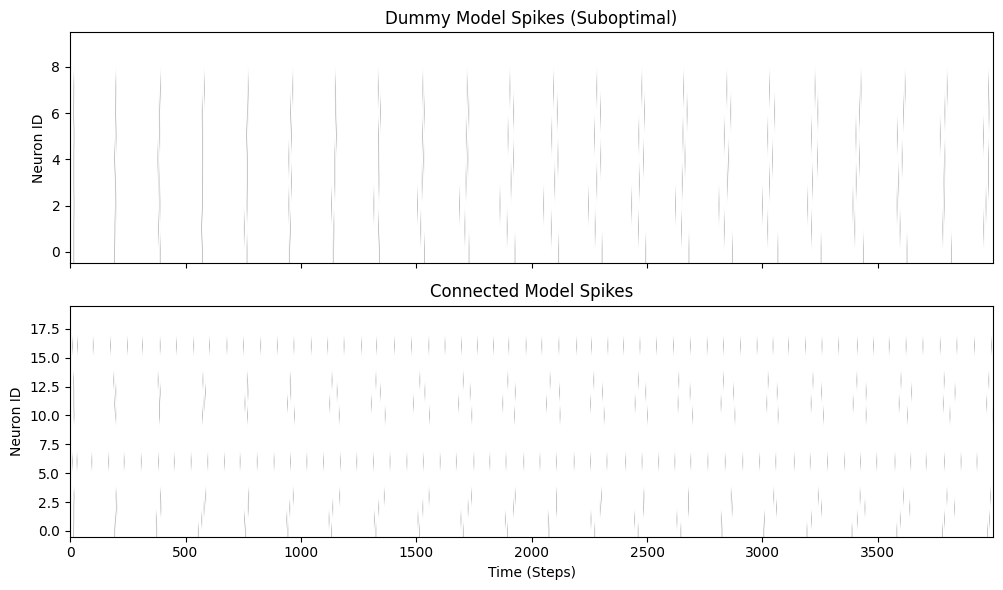

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].imshow(np.array(readout_dummy["spikes"]).T, aspect="auto", cmap="binary", origin="lower")
axes[0].set_title("Dummy Model Spikes (Suboptimal)")
axes[0].set_ylabel("Neuron ID")

axes[1].imshow(np.array(readout_conn["spikes"]).T, aspect="auto", cmap="binary", origin="lower")
axes[1].set_title("Connected Model Spikes")
axes[1].set_xlabel("Time (Steps)")
axes[1].set_ylabel("Neuron ID")
plt.tight_layout()
plt.show()